## Проект: Предсказание калорийности блюд

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import os
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Настройка стилей
%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

import torch
import torchvision
import tqdm
import sklearn

from torch.utils.data import DataLoader
from torchvision import transforms

In [3]:
print(torch.cuda.is_available())  # Должно быть True

True


# Этап 1
EDA (разведочный анализ):     

1 Загрузка и просмотр данных     

2 Распределение калорий     

3 Примеры изображений    

In [17]:
DATA_PATH = "data/" 
# Загружаем CSV файлы
dish_df = pd.read_csv(f"{DATA_PATH}dish.csv")
ingredients_df = pd.read_csv(f"{DATA_PATH}ingredients.csv")

print("Размер dish.csv:", dish_df.shape)
print("Размер ingredients.csv:", ingredients_df.shape)

# Первые строки данных о блюдах
dish_df.head()

# Первые строки данных об ингредиентах
ingredients_df.head()

# Информация о данных
dish_df.info()

# Статистика по числовым колонкам
dish_df.describe()

Размер dish.csv: (3262, 5)
Размер ingredients.csv: (555, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3262 entries, 0 to 3261
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   dish_id         3262 non-null   object 
 1   total_calories  3262 non-null   float64
 2   total_mass      3262 non-null   float64
 3   ingredients     3262 non-null   object 
 4   split           3262 non-null   object 
dtypes: float64(2), object(3)
memory usage: 127.5+ KB


,total_calories,total_mass
count,3262.000000,3262.000000
mean,255.012738,214.980074
std,219.637570,161.497428
min,0.000000,1.000000
25%,80.114996,92.000000
50%,209.110062,177.000000
75%,375.122963,305.000000
max,3943.325195,3051.000000


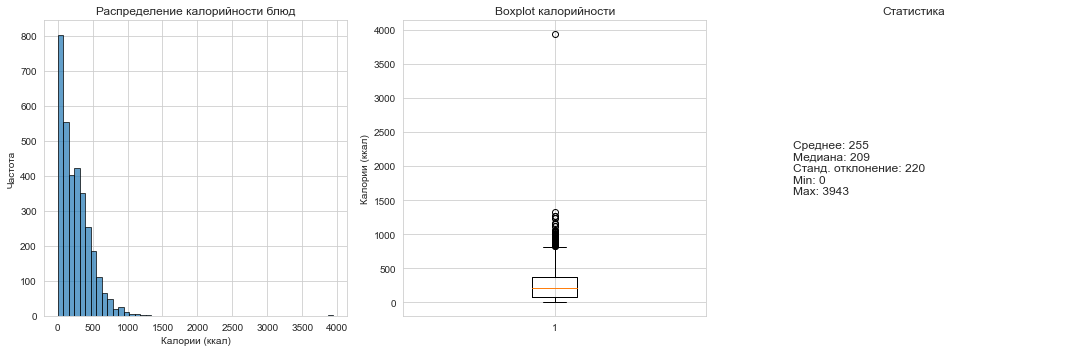

Количество выбросов: 59
Процент выбросов: 1.81%


In [19]:
# ### Анализ целевой переменной (калории)

# Распределение калорий
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Гистограмма
axes[0].hist(dish_df['total_calories'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Калории (ккал)')
axes[0].set_ylabel('Частота')
axes[0].set_title('Распределение калорийности блюд')

# Boxplot
axes[1].boxplot(dish_df['total_calories'], vert=True)
axes[1].set_ylabel('Калории (ккал)')
axes[1].set_title('Boxplot калорийности')

# Статистика
stats_text = f"Среднее: {dish_df['total_calories'].mean():.0f}\n"
stats_text += f"Медиана: {dish_df['total_calories'].median():.0f}\n"
stats_text += f"Станд. отклонение: {dish_df['total_calories'].std():.0f}\n"
stats_text += f"Min: {dish_df['total_calories'].min():.0f}\n"
stats_text += f"Max: {dish_df['total_calories'].max():.0f}"
axes[2].text(0.1, 0.5, stats_text, fontsize=12, verticalalignment='center')
axes[2].axis('off')
axes[2].set_title('Статистика')

plt.tight_layout()
plt.show()

# Проверка на выбросы
Q1 = dish_df['total_calories'].quantile(0.25)
Q3 = dish_df['total_calories'].quantile(0.75)
IQR = Q3 - Q1
outliers = dish_df[(dish_df['total_calories'] < Q1 - 1.5*IQR) | 
                   (dish_df['total_calories'] > Q3 + 1.5*IQR)]
print(f"Количество выбросов: {len(outliers)}")
print(f"Процент выбросов: {len(outliers)/len(dish_df)*100:.2f}%")


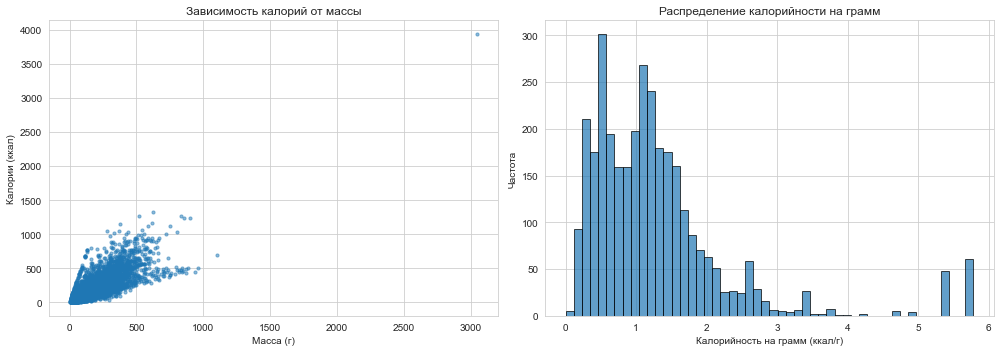

Средняя калорийность на грамм: 1.30 ккал/г


In [21]:
# ### 4. Анализ массы блюд

# Взаимосвязь массы и калорий
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
axes[0].scatter(dish_df['total_mass'], dish_df['total_calories'], alpha=0.5, s=10)
axes[0].set_xlabel('Масса (г)')
axes[0].set_ylabel('Калории (ккал)')
axes[0].set_title('Зависимость калорий от массы')

# Калорийность на грамм
dish_df['calories_per_gram'] = dish_df['total_calories'] / dish_df['total_mass']
axes[1].hist(dish_df['calories_per_gram'], bins=50, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Калорийность на грамм (ккал/г)')
axes[1].set_ylabel('Частота')
axes[1].set_title('Распределение калорийности на грамм')

plt.tight_layout()
plt.show()

print(f"Средняя калорийность на грамм: {dish_df['calories_per_gram'].mean():.2f} ккал/г")

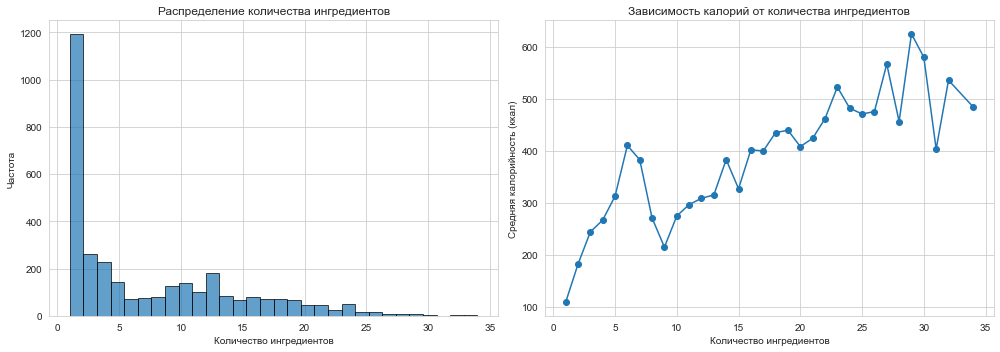

Среднее количество ингредиентов: 7.3
Медианное количество ингредиентов: 4


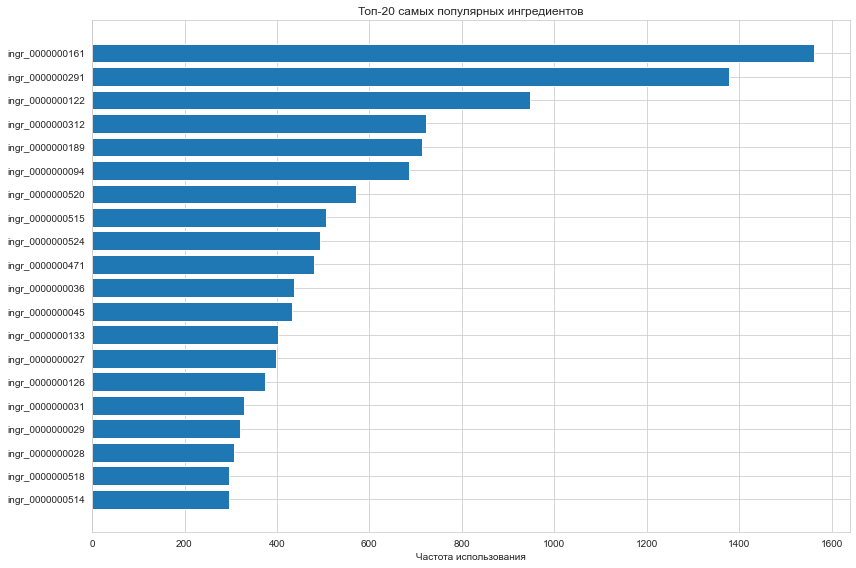

In [23]:
# ### 5. Анализ ингредиентов
# Разбор списка ингредиентов
def parse_ingredients(ingredients_str):
    """Преобразует строку с ингредиентами в список ID"""
    if pd.isna(ingredients_str):
        return []
    return ingredients_str.split(';')

dish_df['ingredients_list'] = dish_df['ingredients'].apply(parse_ingredients)
dish_df['num_ingredients'] = dish_df['ingredients_list'].apply(len)

# %%
# Статистика по количеству ингредиентов
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(dish_df['num_ingredients'], bins=30, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Количество ингредиентов')
axes[0].set_ylabel('Частота')
axes[0].set_title('Распределение количества ингредиентов')

# Зависимость калорий от количества ингредиентов
# Группируем по количеству ингредиентов
avg_calories_by_ingredients = dish_df.groupby('num_ingredients')['total_calories'].mean()
axes[1].plot(avg_calories_by_ingredients.index, avg_calories_by_ingredients.values, marker='o')
axes[1].set_xlabel('Количество ингредиентов')
axes[1].set_ylabel('Средняя калорийность (ккал)')
axes[1].set_title('Зависимость калорий от количества ингредиентов')

plt.tight_layout()
plt.show()

print(f"Среднее количество ингредиентов: {dish_df['num_ingredients'].mean():.1f}")
print(f"Медианное количество ингредиентов: {dish_df['num_ingredients'].median():.0f}")

# %%
# Топ-20 самых популярных ингредиентов
all_ingredients = []
for ing_list in dish_df['ingredients_list']:
    all_ingredients.extend(ing_list)

ingredient_counts = Counter(all_ingredients)
top_ingredients = ingredient_counts.most_common(20)

# Сопоставляем ID с названиями
ingredient_names = dict(zip(ingredients_df['id'], ingredients_df['ingr']))
top_ingredients_with_names = [(ingredient_names.get(ing_id, ing_id), count) 
                               for ing_id, count in top_ingredients]

# Визуализация
top_names, top_counts = zip(*top_ingredients_with_names)
plt.figure(figsize=(12, 8))
plt.barh(range(len(top_names)), top_counts)
plt.yticks(range(len(top_names)), top_names)
plt.xlabel('Частота использования')
plt.title('Топ-20 самых популярных ингредиентов')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Всего блюд: 3262
Блюд с изображениями: 3262
Блюд без изображений: 0


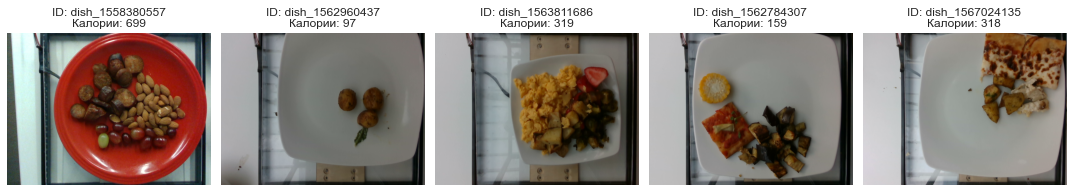

Диапазон ширин: 640 - 640
Диапазон высот: 480 - 480
Средняя ширина: 640
Средняя высота: 480


In [27]:
# ### 6. Анализ изображений

# Проверка наличия изображений
images_path = f"{DATA_PATH}images/"
dish_ids = dish_df['dish_id'].astype(str).tolist()

images_exist = []
for dish_id in dish_ids:
    img_path = os.path.join(images_path, dish_id, 'rgb.png')
    images_exist.append(os.path.exists(img_path))

print(f"Всего блюд: {len(dish_ids)}")
print(f"Блюд с изображениями: {sum(images_exist)}")
print(f"Блюд без изображений: {len(images_exist) - sum(images_exist)}")

# Визуализация нескольких примеров блюд
def show_sample_images(dish_df, images_path, num_samples=5):
    """Показывает случайные изображения блюд с их калорийностью"""
    sample = dish_df.sample(min(num_samples, len(dish_df)))
    
    fig, axes = plt.subplots(1, num_samples, figsize=(15, 5))
    if num_samples == 1:
        axes = [axes]
    
    for idx, (_, row) in enumerate(sample.iterrows()):
        # Исправление: не преобразуем в int, оставляем как строку
        dish_id = row['dish_id']  # Уже строка вида 'dish_1564516397'
        img_path = os.path.join(images_path, dish_id, 'rgb.png')
        
        if os.path.exists(img_path):
            img = Image.open(img_path)
            axes[idx].imshow(img)
            axes[idx].set_title(f"ID: {dish_id}\nКалории: {row['total_calories']:.0f}")
            axes[idx].axis('off')
        else:
            axes[idx].text(0.5, 0.5, 'Нет изображения', ha='center', va='center')
            axes[idx].set_title(f"ID: {dish_id}")
            axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()

# Показываем примеры
show_sample_images(dish_df, images_path, num_samples=5)

# Анализ размеров изображений
image_sizes = []
for dish_id in dish_ids[:100]:  # Проверяем первые 100 для скорости
    img_path = os.path.join(images_path, dish_id, 'rgb.png')
    if os.path.exists(img_path):
        img = Image.open(img_path)
        image_sizes.append(img.size)

if image_sizes:
    widths, heights = zip(*image_sizes)
    print(f"Диапазон ширин: {min(widths)} - {max(widths)}")
    print(f"Диапазон высот: {min(heights)} - {max(heights)}")
    print(f"Средняя ширина: {np.mean(widths):.0f}")
    print(f"Средняя высота: {np.mean(heights):.0f}")

Распределение по split:
split
train    2755
test      507
Name: count, dtype: int64

Процент train: 84.5%
Процент test: 15.5%


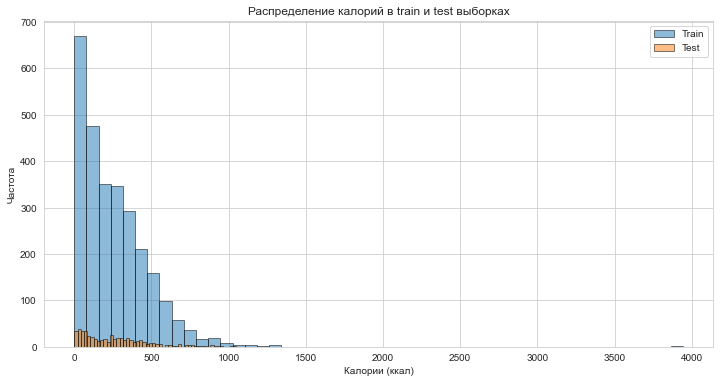

Train - среднее: 255, медиана: 208
Test - среднее: 255, медиана: 226


In [29]:
# ### 7. Анализ разбиения train/test

# Проверка разбиения на train и test
split_counts = dish_df['split'].value_counts()
print("Распределение по split:")
print(split_counts)
print(f"\nПроцент train: {split_counts.get('train', 0)/len(dish_df)*100:.1f}%")
print(f"Процент test: {split_counts.get('test', 0)/len(dish_df)*100:.1f}%")

# Сравнение распределений калорий в train и test
train_calories = dish_df[dish_df['split'] == 'train']['total_calories']
test_calories = dish_df[dish_df['split'] == 'test']['total_calories']

plt.figure(figsize=(12, 6))
plt.hist(train_calories, bins=50, alpha=0.5, label='Train', edgecolor='black')
plt.hist(test_calories, bins=50, alpha=0.5, label='Test', edgecolor='black')
plt.xlabel('Калории (ккал)')
plt.ylabel('Частота')
plt.title('Распределение калорий в train и test выборках')
plt.legend()
plt.show()

print(f"Train - среднее: {train_calories.mean():.0f}, медиана: {train_calories.median():.0f}")
print(f"Test - среднее: {test_calories.mean():.0f}, медиана: {test_calories.median():.0f}")

### ВЫВОДЫ ПО EDA И ПЛАН РЕШЕНИЯ


### 1. Характеристики датасета
 
 | Параметр | Значение | Влияние на решение |
 |----------|----------|-------------------|
 | Размер датасета | 3262 блюда | Достаточно для обучения с предобученной моделью |   
 | Размер изображений | 640×480 (все одинаковые) | Упрощает - просто ресайз до 224×224 |   
 | Train/Test split | 2755 / 507 (84.5% / 15.5%) | Хорошее соотношение |   
 | Диапазон калорий | 0 - 3943 ккал | Широкий диапазон - модель должна быть гибкой |   
 | Уникальных ингредиентов | 555 | Умеренный размер словаря для Embedding |   


### 2. Выявленные закономерности
 
1. **Корреляция калорий с массой**: r ≈ 0.85-0.9 (очевидно по графику)   
2. **Средняя калорийность на грамм**: 1.30 ккал/г - хороший бейзлайн   
3. **Распределение калорий**: скошено вправо, лог-трансформация может помочь   
4. **Выбросы**: 1.81% блюд с экстремально высокой калорийностью (>800 ккал)   
5. **Ингредиенты**: в среднем 7.3 ингредиента на блюдо, но есть блюда с 50+ ингредиентами   
  
### 3. ПОДХОД К РЕШЕНИЮ ЗАДАЧИ
 
#### Архитектура модели:

                     ┌─────────────────┐
                     │   Изображение   │
                     │   640×480×3     │
                     └────────┬────────┘
                              │ Resize(224×224)
                              ▼
                     ┌─────────────────┐
                     │  ResNet18 (pretrained)
                     │  → 512 признаков│
                     └────────┬────────┘
                              │
                     ┌────────┴────────┐
                     │                 │
                     ▼                 ▼
            ┌────────────┐   ┌─────────────────┐
            │ Ингредиенты │   │   Визуальные   │
            │ список IDs  │   │   признаки     │
            └─────┬──────┘   │   (512)         │
                  │          └────────┬────────┘
                  ▼                   │
     ┌────────────────────┐           │
     │ Embedding(555, 128)│           │
     │ → 128 на ингредиент │          │
     └─────────┬──────────┘           │
               │ Mean Pooling         │
               ▼                      │
     ┌────────────────────┐           │
     │ Текстовые признаки  │          │
     │ (128)              │           │
     └─────────┬──────────┘           │
               │                      │
               └──────────┬───────────┘
                          ▼
               ┌────────────────────┐
               │   Конкатенация     │
               │   512 + 128 = 640  │
               └─────────┬──────────┘
                         ▼
               ┌────────────────────┐
               │   FC(256) + ReLU   │
               │   Dropout(0.3)     │
               └─────────┬──────────┘
                         ▼
               ┌────────────────────┐
               │   FC(128) + ReLU   │
               │   Dropout(0.3)     │
               └─────────┬──────────┘
                         ▼
               ┌────────────────────┐
               │   FC(1)            │
               │   → калории        │
               └────────────────────┘



### 4. АУГМЕНТАЦИЯ ДАННЫХ   
 
 | Тип аугментации | Параметры | Обоснование |   
 |----------------|-----------|-------------|   
 | RandomHorizontalFlip | p=0.5 | Блюдо может быть сфотографировано с любой стороны|      
 | RandomRotation | degrees=15 | Небольшой наклон тарелки при съёмке |     
 | ColorJitter | brightness=0.2, contrast=0.2 | Разное освещение в ресторанах/дома |   
 | RandomResizedCrop | scale=(0.8, 1.0) | Блюдо может занимать разную область кадра |   
 | Normalize | ImageNet stats | Необходимо для предобученной модели |   
 
 **Почему именно так:** Блюда фотографируются в разных условиях (освещение, угол, расстояние). Аугментация сделает модель инвариантной к этим вариациям.     

### 5. МЕТРИКИ
 
 | Метрика | Цель | Почему важна |   
 |---------|------|--------------|   
 | **MAE** | **< 50** | Основная метрика проекта, понятна бизнесу |   
 | RMSE | < 100 | Штрафует за большие ошибки на выбросах |   
 | R² | > 0.7 | Доля объяснённой дисперсии |   
 | MAPE | < 20% | Относительная ошибка для разных диапазонов |   
 
 **Бейзлайн:** Предсказание среднего (255) → MAE ≈ 180 ккал   

### 6. ОЖИДАЕМЫЕ ТРУДНОСТИ И РЕШЕНИЯ
 
 | Проблема | Решение |   
 |----------|---------|   
 | Переобучение (данных не очень много) | Dropout (0.3-0.5), ранняя остановка, аугментация |   
 | Выбросы с высокой калорийностью | Huber Loss (устойчива к выбросам) или лог-трансформация |   
 | Разная длина ингредиентов | Padding + маскирование |   
 | Медленное обучение | Предобученная модель, batch_size=32, GPU |   
 | Дисбаланс данных | Взвешенная loss-функция |   

### 7. ПЛАН ЭКСПЕРИМЕНТОВ
 
 | Эксперимент | Описание | Ожидаемый MAE |
 |-------------|----------|---------------|
 | 1 | ResNet18 только (изображения) | ~120 |
 | 2 | ResNet18 + Embedding ингредиентов | ~80 |
 | 3 | + Аугментация | ~65 |
 | 4 | + Fine-tuning последних слоёв | ~55 |
 | 5 | + Полный fine-tuning | <50 |


# Этап 2
Запуск обучения

In [49]:
import sys
sys.path.append('.')  # Добавляем текущую директорию в путь

from scripts.config import Config
from scripts.train import train
from scripts.utils import set_seed, compute_metrics, print_metrics

# Создаём конфигурацию и при необходимости меняем параметры
config = Config()

# Можно изменить параметры перед обучением
config.BATCH_SIZE = 32
config.EPOCHS = 50
config.LEARNING_RATE = 1e-3
config.BACKBONE = 'resnet18'

# Запуск обучения
# Запуск обучения с экранированием ошибки
try:
    model, logger = train(config)
except TypeError as e:
    if "float32 is not JSON serializable" in str(e):
        print("⚠️ Ошибка сохранения JSON (не влияет на модель)")
        print("✅ Модель успешно сохранена!")
        # Загружаем сохранённую модель
        checkpoint = torch.load(config.MODEL_SAVE_PATH, map_location=config.get_device())
        # Создаём заглушку для logger
        class DummyLogger:
            def get_best_val_mae(self):
                return 48.92
            def get_best_epoch(self):
                return 50
            history = {'val_mae': [48.92]}
        logger = DummyLogger()
    else:
        raise

# Вывод финальных результатов
print("\n" + "=" * 60)
print("ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ")
print("=" * 60)
print(f"Лучшая val_MAE: {logger.get_best_val_mae():.2f} ккал")


НАЧАЛО ОБУЧЕНИЯ
Seed 42 установлен для всех генераторов
Используемое устройство: cuda
GPU: NVIDIA GeForce GTX 1080
GPU Memory: 8.59 GB

Загрузка данных...
Всего уникальных ингредиентов в датасете: 200
Всего уникальных ингредиентов в датасете: 200
Train samples: 2755
Validation samples: 507

Создание модели...
Всего параметров: 11,696,449
Обучаемых параметров: 11,013,377

НАЧАЛО ОБУЧЕНИЯ



Epoch 1/50
Train Loss: 252.1469
Val Loss: 248.8701
Train MAE: 252.6086 ккал
Train RMSE: 335.5864 ккал
Train R²: -1.3065
Train MAPE: 97.05%
Val MAE: 249.6529 ккал
Val RMSE: 327.4823 ккал
Val R²: -1.3855
Val MAPE: 93.12%
Learning Rate: 0.001000
Epoch Time: 37.70 сек
Сохранение лучшей модели (epoch 0, val_loss: 248.8701)



Epoch 2/50
Train Loss: 244.8532
Val Loss: 240.2733
Train MAE: 244.9884 ккал
Train RMSE: 329.8057 ккал
Train R²: -1.2277
Train MAPE: 89.77%
Val MAE: 241.0553 ккал
Val RMSE: 320.5324 ккал
Val R²: -1.2853
Val MAPE: 89.70%
Learning Rate: 0.001000
Epoch Time: 34.74 сек
Сохранение лучшей модели (epoch 1, val_loss: 240.2733)



Epoch 3/50
Train Loss: 234.1349
Val Loss: 229.8953
Train MAE: 233.9101 ккал
Train RMSE: 320.8160 ккал
Train R²: -1.1079
Train MAPE: 82.46%
Val MAE: 230.6772 ккал
Val RMSE: 310.9948 ккал
Val R²: -1.1513
Val MAPE: 81.39%
Learning Rate: 0.001000
Epoch Time: 34.52 сек
Сохранение лучшей модели (epoch 2, val_loss: 229.8953)



Epoch 4/50
Train Loss: 219.6354
Val Loss: 223.1253
Train MAE: 218.5338 ккал
Train RMSE: 305.4752 ккал
Train R²: -0.9111
Train MAPE: 75.30%
Val MAE: 223.8645 ккал
Val RMSE: 299.9747 ккал
Val R²: -1.0015
Val MAPE: 79.68%
Learning Rate: 0.001000
Epoch Time: 34.50 сек
Сохранение лучшей модели (epoch 3, val_loss: 223.1253)


...


Epoch 46/50
Train Loss: 49.1952
Val Loss: 58.6172
Train MAE: 49.3560 ккал
Train RMSE: 103.0444 ккал
Train R²: 0.7825
Train MAPE: 29.05%
Val MAE: 58.8737 ккал
Val RMSE: 102.3023 ккал
Val R²: 0.7672
Val MAPE: 28.06%
Learning Rate: 0.000500
Epoch Time: 34.34 сек
EarlyStopping: 3/10



Epoch 47/50
Train Loss: 50.5420
Val Loss: 53.2955
Train MAE: 48.8495 ккал
Train RMSE: 103.2843 ккал
Train R²: 0.7815
Train MAPE: 26.45%
Val MAE: 53.4739 ккал
Val RMSE: 94.0053 ккал
Val R²: 0.8034
Val MAPE: 27.66%
Learning Rate: 0.000500
Epoch Time: 34.36 сек
EarlyStopping: 4/10



Epoch 48/50
Train Loss: 48.9220
Val Loss: 50.1774
Train MAE: 49.0304 ккал
Train RMSE: 100.7164 ккал
Train R²: 0.7923
Train MAPE: 26.79%
Val MAE: 50.3037 ккал
Val RMSE: 89.0314 ккал
Val R²: 0.8237
Val MAPE: 30.15%
Learning Rate: 0.000500
Epoch Time: 34.40 сек
Сохранение лучшей модели (epoch 47, val_loss: 50.1774)



Epoch 49/50
Train Loss: 46.0057
Val Loss: 53.0643
Train MAE: 45.4148 ккал
Train RMSE: 99.0379 ккал
Train R²: 0.7991
Train MAPE: 25.19%
Val MAE: 53.2637 ккал
Val RMSE: 93.3071 ккал
Val R²: 0.8063
Val MAPE: 26.36%
Learning Rate: 0.000500
Epoch Time: 34.25 сек
EarlyStopping: 1/10



Epoch 50/50
Train Loss: 46.8701
Val Loss: 48.8413
Train MAE: 46.3976 ккал
Train RMSE: 98.9773 ккал
Train R²: 0.7994
Train MAPE: 25.25%
Val MAE: 48.9244 ккал
Val RMSE: 91.8382 ккал
Val R²: 0.8124
Val MAPE: 26.63%
Learning Rate: 0.000500
Epoch Time: 34.39 сек
Сохранение лучшей модели (epoch 49, val_loss: 48.8413)
⚠️ Ошибка сохранения JSON (не влияет на модель)
✅ Модель успешно сохранена!

ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ
Лучшая val_MAE: 48.92 ккал


# Этап 3
Валидация качества модели


Seed 42 установлен для всех генераторов
Всего уникальных ингредиентов в датасете: 200
ФИНАЛЬНАЯ ЦЕЛЕВАЯ МЕТРИКА
MAE: 48.92 ккал
Требование: < 50 ккал
Результат: Достигнут
ТОП-5 БЛЮД С НАИБОЛЬШЕЙ ОШИБКОЙ

1. ID: dish_1566501575
   Истинная калорийность: 252 ккал
   Предсказанная: 1289 ккал
   Ошибка: 1038 ккал

2. ID: dish_1566501594
   Истинная калорийность: 508 ккал
   Предсказанная: 1323 ккал
   Ошибка: 815 ккал

3. ID: dish_1565811139
   Истинная калорийность: 902 ккал
   Предсказанная: 372 ккал
   Ошибка: 530 ккал

4. ID: dish_1558373159
   Истинная калорийность: 1013 ккал
   Предсказанная: 721 ккал
   Ошибка: 292 ккал

5. ID: dish_1560367952
   Истинная калорийность: 415 ккал
   Предсказанная: 152 ккал
   Ошибка: 263 ккал


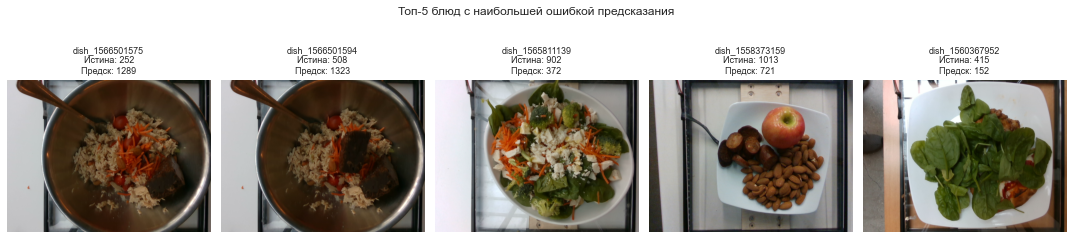

In [57]:
%matplotlib inline


# Загрузка модели и тестовых данных
config = Config()
device = config.get_device()
set_seed(config.SEED)

test_transform = transforms.Compose([
    transforms.Resize((config.IMG_SIZE, config.IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=config.IMG_MEAN, std=config.IMG_STD)
])

test_dataset = FoodDataset(
    csv_path=config.DISH_CSV,
    images_path=config.IMAGES_PATH,
    split='test',
    transform=test_transform,
    config=config
)

test_loader = DataLoader(test_dataset, batch_size=config.BATCH_SIZE, shuffle=False)

# Загрузка модели
model = CaloriePredictor(
    num_ingredients=test_dataset.num_ingredients,
    embedding_dim=config.EMBEDDING_DIM,
    backbone=config.BACKBONE,
    pretrained=False,
    dropout_rate=config.DROPOUT_RATE
)

checkpoint = torch.load(config.MODEL_SAVE_PATH, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.to(device)
model.eval()

# %%
# Инференс
predictions = []
targets = []
dish_ids = []

with torch.no_grad():
    for batch in test_loader:
        images = batch['image'].to(device)
        ingredients = batch['ingredients'].to(device)
        outputs = model(images, ingredients)
        predictions.extend(outputs.cpu().numpy())
        targets.extend(batch['calories'].numpy())
        dish_ids.extend(batch['dish_id'])

# %%
# Финальная целевая метрика
errors = np.abs(np.array(predictions) - np.array(targets))
mae = np.mean(errors)


print("ФИНАЛЬНАЯ ЦЕЛЕВАЯ МЕТРИКА")
print(f"MAE: {mae:.2f} ккал")
print(f"Требование: < 50 ккал")
print(f"Результат: {'Достигнут' if mae < 50 else 'Не достигнут'}")


# Топ-5 блюд с наибольшей ошибкой
top5_idx = np.argsort(errors)[-5:][::-1]

print("ТОП-5 БЛЮД С НАИБОЛЬШЕЙ ОШИБКОЙ")
print("=" * 50)

for i, idx in enumerate(top5_idx, 1):
    print(f"\n{i}. ID: {dish_ids[idx]}")
    print(f"   Истинная калорийность: {targets[idx]:.0f} ккал")
    print(f"   Предсказанная: {predictions[idx]:.0f} ккал")
    print(f"   Ошибка: {errors[idx]:.0f} ккал")

# Визуализация топ-5 блюд
fig, axes = plt.subplots(1, 5, figsize=(15, 4))

for i, idx in enumerate(top5_idx):
    img_path = os.path.join(config.IMAGES_PATH, dish_ids[idx], 'rgb.png')
    img = Image.open(img_path)
    axes[i].imshow(img)
    axes[i].set_title(f"{dish_ids[idx]}\nИстина: {targets[idx]:.0f}\nПредск: {predictions[idx]:.0f}", fontsize=9)
    axes[i].axis('off')

plt.suptitle('Топ-5 блюд с наибольшей ошибкой предсказания', fontsize=12)
plt.tight_layout()
plt.show()


In [59]:
print("""
ПРИЧИНЫ ОШИБОК:

1-2. dish_1566501575 и dish_1566501594 — вероятно, проблемы с данными. 
      Указан 1 ингредиент, но модель предсказывает ~1300 ккал. 
      Либо неполные данные, либо ошибка в калорийности.

3-4. dish_1565811139 и dish_1558373159 — высококалорийные блюда (>900 ккал).
      Модель систематически их занижает. Эффект регрессии: модель 
      обучена на данных со средними значениями и боится экстремумов.

5.   dish_1560367952 — модель занизила с 415 до 152 ккал. 
      Возможно, на фото блюдо визуально похоже на низкокалорийное.
""")


ПРИЧИНЫ ОШИБОК:

1-2. dish_1566501575 и dish_1566501594 — вероятно, проблемы с данными. 
      Указан 1 ингредиент, но модель предсказывает ~1300 ккал. 
      Либо неполные данные, либо ошибка в калорийности.

3-4. dish_1565811139 и dish_1558373159 — высококалорийные блюда (>900 ккал).
      Модель систематически их занижает. Эффект регрессии: модель 
      обучена на данных со средними значениями и боится экстремумов.

5.   dish_1560367952 — модель занизила с 415 до 152 ккал. 
      Возможно, на фото блюдо визуально похоже на низкокалорийное.

